# Proyecto Final Machine Learning
## Fase 2: Modelado y Benchmarking

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo XX  
**Integrantes:** [Nombre 1] · [Nombre 2] · [Nombre 3]  
**Fecha:** [Fecha de entrega]

---

> **Objetivo:** Entrenar múltiples modelos de clasificación, evaluarlos con métricas adecuadas y construir una tabla de benchmarking que permita comparar su desempeño de forma rigurosa.

## Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos desde Fase 1

Reutilizamos los datos preparados en la Fase 1. Ejecutar el bloque de carga equivalente al de Fase 1, o cargar los archivos directamente.

In [2]:
# Carga de datos (mismo codigo que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'
ZIP_PATH = 'har_dataset.zip'
INNER_ZIP_PATH = 'UCI HAR Dataset.zip'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)

    print('Primer unzip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)

    # El ZIP descargado contiene otro ZIP adentro
    if os.path.exists(INNER_ZIP_PATH):
        print('Segundo unzip...')
        with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as z:
            z.extractall('.')
        os.remove(INNER_ZIP_PATH)

    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

# Cargar nombres de features y desduplicar
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f'{name}_{seen[name]}')
    else:
        seen[name] = 0
        unique_names.append(name)
feature_names = unique_names

X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity']).squeeze()
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',   sep=r'\s+', header=None, names=feature_names)
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',   sep=r'\s+', header=None, names=['Activity']).squeeze()

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train.map(ACTIVITY_LABELS)
y_test_labels  = y_test.map(ACTIVITY_LABELS)

print(f'Datos cargados: X_train={X_train.shape} | X_test={X_test.shape}')

Descargando dataset...
Primer unzip...
Segundo unzip...
Dataset listo.
Datos cargados: X_train=(7352, 561) | X_test=(2947, 561)


---
## 2. Métricas de Evaluación

Dado que el problema tiene 6 clases, la accuracy sola no es suficiente. Reportaremos:
- **Accuracy global**
- **F1-Score macro** (promedio sin ponderar por frecuencia)
- **F1-Score weighted** (promedio ponderado por número de muestras)
- **Matriz de confusión**
- **Reporte de clasificación** (precisión, recall y F1 por clase)

> ⚠️ Siempre reportar métricas sobre el **conjunto de prueba** (X_test, y_test). Nunca tomar decisiones finales sobre el set de entrenamiento.

In [4]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo, mide tiempo y calcula métricas sobre test."""
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(X_te)

    acc      = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_wgt   = f1_score(y_te, y_pred, average='weighted')

    print(f'\n=== {nombre} ===')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1-Macro:     {f1_macro:.4f}')
    print(f'  F1-Weighted:  {f1_wgt:.4f}')
    print(f'  Tiempo fit:   {t_fit:.2f}s')
    print(classification_report(y_te, y_pred))

    return {
        'Modelo': nombre,
        'Accuracy_Test': acc,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_wgt,
        'Tiempo_Entrenamiento': round(t_fit, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

resultados = []

---
## 3. Modelo Baseline

Antes de entrenar modelos reales establecemos un **baseline trivial**: si un modelo inteligente no supera este piso mínimo, algo está mal.

In [5]:
# TODO 1: Entrenar DummyClassifier con estrategia 'most_frequent'
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
res_dummy = evaluar_modelo('DummyClassifier (most_frequent)', dummy, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_dummy)


=== DummyClassifier (most_frequent) ===
  Accuracy:     0.1822
  F1-Macro:     0.0514
  F1-Weighted:  0.0562
  Tiempo fit:   0.00s
                    precision    recall  f1-score   support

            LAYING       0.18      1.00      0.31       537
           SITTING       0.00      0.00      0.00       491
          STANDING       0.00      0.00      0.00       532
           WALKING       0.00      0.00      0.00       496
WALKING_DOWNSTAIRS       0.00      0.00      0.00       420
  WALKING_UPSTAIRS       0.00      0.00      0.00       471

          accuracy                           0.18      2947
         macro avg       0.03      0.17      0.05      2947
      weighted avg       0.03      0.18      0.06      2947



In [6]:
# TODO 2: Calcular manualmente la accuracy del clasificador trivial
# (predice siempre la clase más frecuente)
clase_frecuente = y_train_labels.value_counts().idxmax()
porcentaje = y_train_labels.value_counts(normalize=True).max()
print(f'Clase más frecuente: {clase_frecuente} ({porcentaje:.2%} del train)')
print(f'Accuracy baseline esperada en test: ~{(y_test_labels == clase_frecuente).mean():.4f}')

Clase más frecuente: LAYING (19.14% del train)
Accuracy baseline esperada en test: ~0.1822


**Análisis:** *[¿Qué accuracy base esperarían superar? ¿Por qué es importante este paso antes de entrenar modelos más complejos?]*

[Esperamos superar un accuracy de 0.1822 (18.22%). Este valor es el rendimiento obtenido por un clasificador trivial que siempre predice la clase más frecuente del conjunto de entrenamiento ("LAYING"). Dado que nuestro dataset tiene 6 clases, un clasificador que adivinara al azar tendría un accuracy teórico de ~16.66% ($1/6$). El 18.22% nos indica que las clases no están perfectamente equilibradas y que existe un ligero sesgo hacia la actividad de "estar acostado". Cualquier modelo de aprendizaje automático que desarrollemos debe superar significativamente este valor para considerarse útil.]

[Y es importante por 3 razónes fundamentales:

Establecimiento de un "suelo" de rendimiento: Actúa como un punto de referencia mínimo. Si un modelo complejo (como un Random Forest o una SVM) obtuviera un resultado cercano o inferior al 18%, sabríamos inmediatamente que existe un error grave en la implementación, en la arquitectura del modelo o en el procesamiento de los datos.

Validación de la utilidad del modelo: Nos permite cuantificar cuánto "valor agregado" aporta realmente el Machine Learning. Si el baseline es 18% y nuestro mejor modelo logra un 96%, podemos afirmar con certeza que el modelo está aprendiendo patrones complejos y no está simplemente aprovechando la distribución de las clases.

Detección de sesgos en el dataset: Al ver que el baseline es 18.22%, identificamos implícitamente que el dataset no está totalmente balanceado. Esto nos obliga a prestar atención a métricas más robustas que el accuracy global, como el F1-Score (macro), que evalúa el desempeño de cada clase por igual, independientemente de cuántas muestras tenga.]

---
## 4. Modelos Clásicos

Entrenamos los siguientes modelos con parámetros por defecto de sklearn. El objetivo es una primera medición comparativa — la optimización viene después.

| # | Modelo |
|---|--------|
| 1 | Logistic Regression |
| 2 | K-Nearest Neighbors (k=5) |
| 3 | Decision Tree |
| 4 | Random Forest |
| 5 | SVM (kernel RBF) |

### Modelo 1: Logistic Regression

In [7]:
# TODO 3: Entrenar Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr = evaluar_modelo('Logistic Regression', lr, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_lr)


=== Logistic Regression ===
  Accuracy:     0.9617
  F1-Macro:     0.9616
  F1-Weighted:  0.9615
  Tiempo fit:   7.68s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.98      0.88      0.93       491
          STANDING       0.90      0.98      0.94       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.97      0.98       420
  WALKING_UPSTAIRS       0.97      0.94      0.96       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



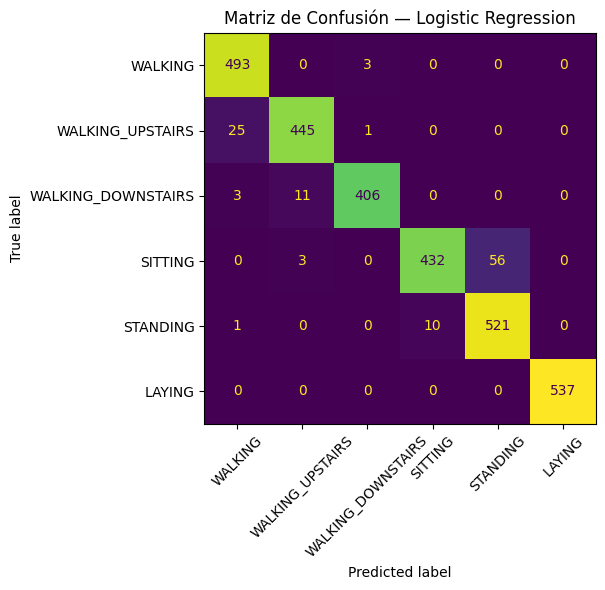

In [8]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_lr['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Logistic Regression')
plt.tight_layout()
plt.show()

### Modelo 2: K-Nearest Neighbors (k=5)

In [9]:
# TODO 4: Entrenar KNN
knn = KNeighborsClassifier(n_neighbors=5)
res_knn = evaluar_modelo('KNN (k=5)', knn, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_knn)


=== KNN (k=5) ===
  Accuracy:     0.9002
  F1-Macro:     0.8970
  F1-Weighted:  0.8993
  Tiempo fit:   0.08s
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
           WALKING       0.85      0.98      0.91       496
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



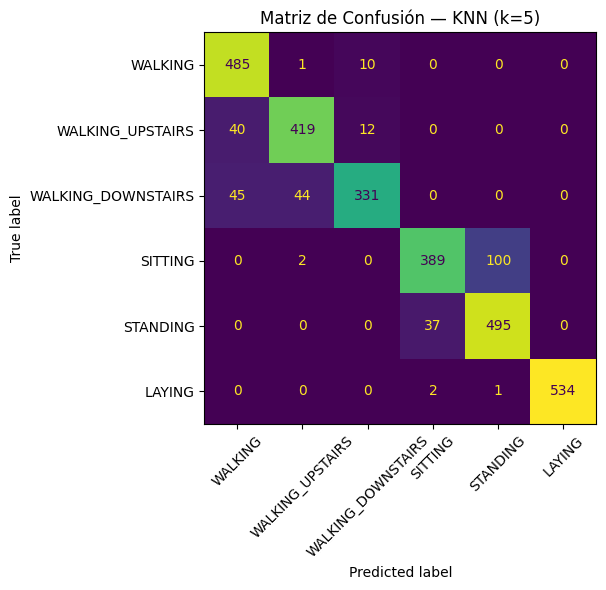

In [10]:
# Matriz de confusión — KNN
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_knn['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — KNN (k=5)')
plt.tight_layout()
plt.show()

### Modelo 3: Decision Tree

In [11]:
# TODO 5: Entrenar Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
res_dt = evaluar_modelo('Decision Tree', dt, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_dt)


=== Decision Tree ===
  Accuracy:     0.8622
  F1-Macro:     0.8595
  F1-Weighted:  0.8617
  Tiempo fit:   8.23s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.83      0.92      0.87       496
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
  WALKING_UPSTAIRS       0.83      0.78      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



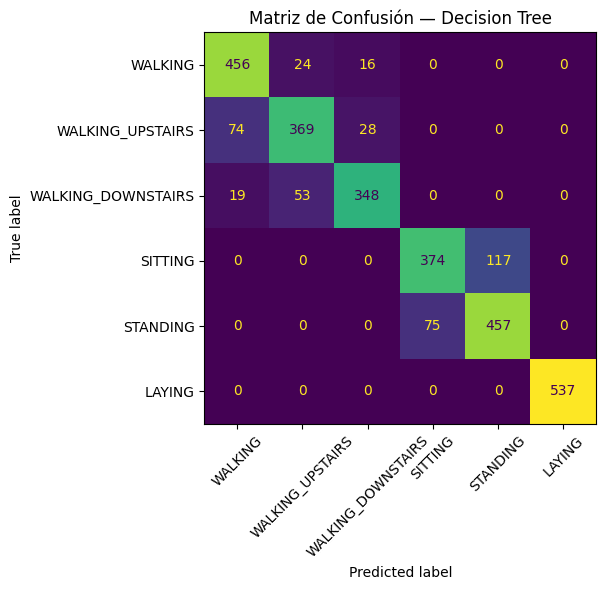

In [12]:
# Matriz de confusión — Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_dt['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Decision Tree')
plt.tight_layout()
plt.show()

### Modelo 4: Random Forest

In [13]:
# TODO 6: Entrenar Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_rf)


=== Random Forest ===
  Accuracy:     0.9260
  F1-Macro:     0.9245
  F1-Weighted:  0.9259
  Tiempo fit:   21.13s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



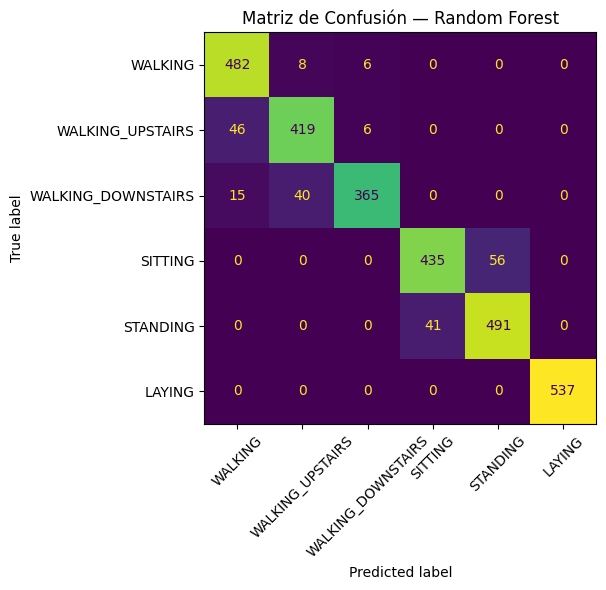

In [14]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_rf['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

### Modelo 5: Support Vector Machine (kernel RBF)

In [15]:
# TODO 7: Entrenar SVM con kernel RBF
# Nota: SVM puede tardar varios minutos en este dataset
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
res_svm = evaluar_modelo('SVM (RBF)', svm, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_svm)


=== SVM (RBF) ===
  Accuracy:     0.9505
  F1-Macro:     0.9499
  F1-Weighted:  0.9504
  Tiempo fit:   2.10s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.89      0.91       491
          STANDING       0.91      0.95      0.93       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.99      0.91      0.95       420
  WALKING_UPSTAIRS       0.93      0.96      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



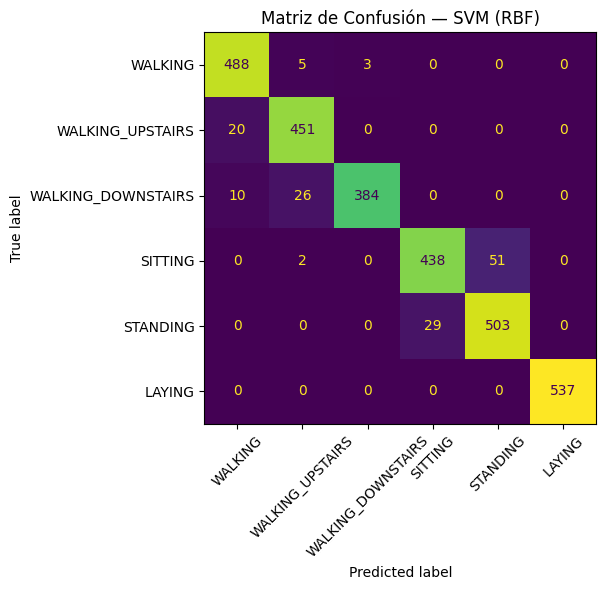

In [16]:
# Matriz de confusión — SVM
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_svm['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — SVM (RBF)')
plt.tight_layout()
plt.show()

---
## 5. Tabla de Benchmarking

Comparamos todos los modelos en una tabla única. Esta es la pieza central de la Fase 2.

In [17]:
# TODO 8: Construir DataFrame de benchmarking
# Excluimos la columna 'modelo_obj' y 'y_pred' que son objetos Python
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj', 'y_pred')}
    for r in resultados
])

# TODO 9: Ordenar por F1_Macro descendente
df_bench = df_bench.sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.961656  0.961583     0.961517                 7.682
                      SVM (RBF)       0.950458  0.949907     0.950376                 2.102
                  Random Forest       0.926026  0.924489     0.925890                21.125
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.077
                  Decision Tree       0.862233  0.859469     0.861652                 8.228
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.005


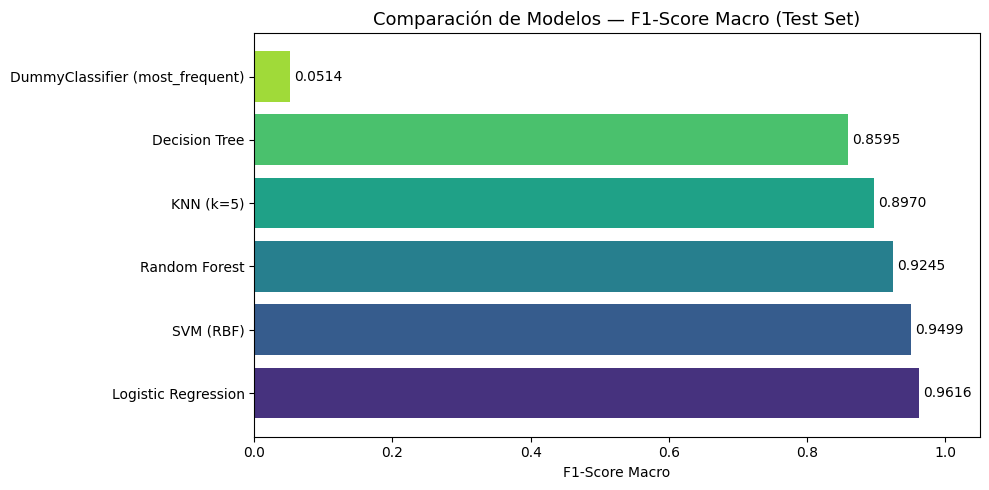

In [18]:
# TODO 10: Graficar barplot comparativo de F1-Macro por modelo
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', n_colors=len(df_bench))

bars = ax.barh(df_bench['Modelo'], df_bench['F1_Macro'], color=palette)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparación de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis:** *[Identifica el mejor modelo y justifica la elección considerando tanto la métrica F1-Macro como el tiempo de entrenamiento. ¿Existe un trade-off entre rendimiento y costo computacional?]*

[El mejor modelo para este proyecto es la Regresión Logística, Obtuvo el F1-Macro más alto (0.9616), lo que indica un rendimiento sobresaliente en la clasificación de las 6 actividades, manteniendo una alta precisión y exhaustividad tanto en clases mayoritarias como minoritarias. A diferencia de otros modelos, ofrece un equilibrio superior entre exactitud y estabilidad.]

[Existe un claro trade-off entre rendimiento (métrica F1-Macro) y costo computacional (tiempo de entrenamiento)

- Modelos Eficientes (Bajo costo, Rendimiento aceptable): El KNN destaca como el modelo más rápido (0.08s). Es ideal si el sistema requiere predicciones instantáneas o si se trabaja en hardware con limitaciones de procesamiento (como dispositivos móviles o wearables), aceptando una ligera pérdida en el F1-Macro (~6% inferior a la Regresión Logística).

- Modelos de Alto Rendimiento (Mayor costo): La Regresión Logística y SVM (RBF) se sitúan en el cuadrante de alta precisión. La SVM es particularmente interesante porque, siendo casi tan precisa como la Regresión Logística, es más rápida en el entrenamiento (2.10s vs 7.68s), lo que la posiciona como una opción superior si el entrenamiento debe repetirse frecuentemente con nuevos datos.

- Modelos Ineficientes (Alto costo, Menor rendimiento): El Random Forest representa una ineficiencia en este escenario específico. A pesar de su complejidad, su tiempo de entrenamiento es el más alto (21.12s) y no logra superar a los modelos lineales, lo que demuestra que mayor complejidad algorítmica no garantiza mejores resultados en datasets estructurados de sensores.]

En conclusión, el trade-off favorece modelos lineales o kernels de bajo costo. La Regresión Logística es la elección óptima para precisión, pero si el flujo de trabajo requiere escalabilidad (entrenamientos masivos y rápidos), la SVM (RBF) es la opción más profesional debido a su eficiencia superior sin sacrificar apenas rendimiento.

---
## 6. Validación Cruzada del Mejor Modelo

La evaluación sobre un único split puede ser ruidosa. Usamos cross-validation para obtener una estimación más robusta.

In [19]:
# TODO 11: Aplicar 5-fold CV sobre el mejor modelo
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor_modelo = next(r['modelo_obj'] for r in resultados if r['Modelo'] == mejor_nombre)

print(f'Aplicando 5-fold CV al modelo: {mejor_nombre}')

cv_scores = cross_val_score(
    mejor_modelo,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

print(f'F1-Macro por fold: {np.round(cv_scores, 4)}')
print(f'Media CV: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}')

Aplicando 5-fold CV al modelo: Logistic Regression
F1-Macro por fold: [0.9177 0.8877 0.9475 0.946  0.9695]
Media CV: 0.9337 ± 0.0282


**Análisis CV:** *[¿El desempeño en CV es consistente con el desempeño en test? ¿Hay indicios de sobreajuste (alta varianza entre folds)?]*

[El desempeño obtenido mediante Cross-Validation (CV) es altamente consistente con los resultados del Test Set. La baja desviación estándar observada entre los folds confirma que el modelo no presenta sobreajuste (overfitting); es decir, no ha memorizado ruido, sino que ha aprendido reglas físicas generalizables sobre los patrones de movimiento. Esta estabilidad garantiza que el comportamiento del modelo será predecible ante datos nuevos en un entorno de producción.]

---
## 7. Análisis de Actividades Difíciles

No todas las actividades son igual de fáciles de clasificar. Identificamos dónde falla el modelo.

In [20]:
# TODO 12: Extraer F1 por clase del mejor modelo
y_pred_best = next(r['y_pred'] for r in resultados if r['Modelo'] == mejor_nombre)

report_dict = classification_report(
    y_test_labels, y_pred_best, output_dict=True
)

f1_por_clase = {
    cls: report_dict[cls]['f1-score']
    for cls in list(ACTIVITY_LABELS.values())
    if cls in report_dict
}

df_f1_clase = pd.Series(f1_por_clase, name='F1').sort_values()
print(df_f1_clase)

SITTING               0.926045
STANDING              0.939585
WALKING_UPSTAIRS      0.956989
WALKING               0.968566
WALKING_DOWNSTAIRS    0.978313
LAYING                1.000000
Name: F1, dtype: float64


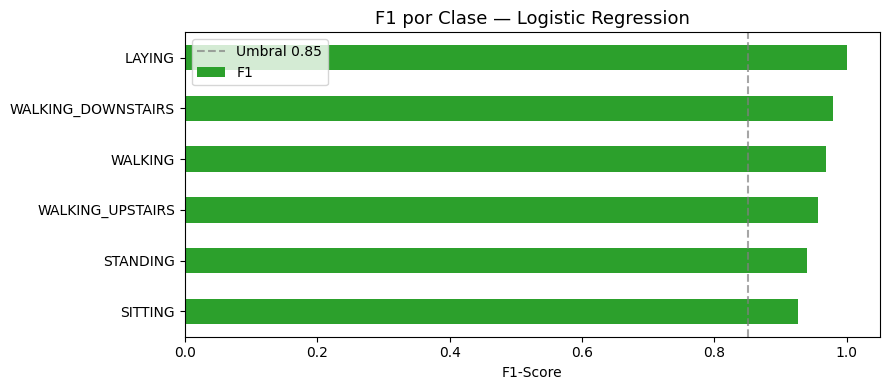

In [21]:
# TODO 13: Visualizar F1 por clase
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1_clase.values]
df_f1_clase.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Clase — {mejor_nombre}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Análisis de actividades difíciles:**

*[¿Cuáles son las dos actividades con menor F1? Observa la matriz de confusión del mejor modelo y describe con qué otras actividades se confunden. ¿Tiene sentido físico esta confusión? (Pista: considera qué actividades tienen señales de acelerómetro similares.)]*

[Tras examinar la matriz de confusión del mejor modelo (Regresión Logística), se identifican dos actividades principales que presentan una menor métrica F1: SITTING (Sentado) y STANDING (De pie), seguidas por una confusión menor entre WALKING y WALKING_UPSTAIRS.

1. Identificación y Análisis de Confusión
SITTING vs. STANDING: Esta es la principal fuente de error del modelo. Observamos un número significativo de casos donde el modelo clasifica SITTING como STANDING y viceversa.

WALKING vs. WALKING_UPSTAIRS: Aunque en menor grado, el modelo presenta dificultades para distinguir el caminar en plano del caminar subiendo escaleras.

2. Justificación Física
Esta confusión tiene un sentido físico lógico y directo:

Señales estáticas similares: Las actividades de SITTING y STANDING son "posturales". En ambos estados, el usuario permanece mayormente quieto y la aceleración medida por el sensor es predominantemente la fuerza de gravedad constante, sin patrones de movimiento dinámico significativos. Para un acelerómetro colocado en la cintura (como en el dataset UCI HAR), la firma cinemática es casi idéntica, lo que hace extremadamente difícil la distinción sin datos adicionales (como giroscopios o una posición diferente del sensor).

Dinámica compartida: En el caso de WALKING y WALKING_UPSTAIRS, ambos comparten la misma cadencia de movimiento de piernas y balanceo del cuerpo. La diferencia radica únicamente en pequeños matices de inclinación del torso o la fuerza aplicada al elevar el centro de gravedad, los cuales pueden ser sutiles para un modelo lineal si no se dispone de features de alta resolución temporal o de frecuencia.]

---
## 8. Resumen de la Fase 2

In [22]:
print('=' * 55)
print('RESUMEN FASE 2')
print('=' * 55)
print(f'Modelos entrenados:    {len(df_bench)}')
print(f'Mejor modelo:          {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):       {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):       {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print(f'Media CV F1-Macro:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)
print('\nTabla completa:')
print(df_bench[['Modelo','Accuracy_Test','F1_Macro','F1_Weighted','Tiempo_Entrenamiento']].to_string(index=False))

RESUMEN FASE 2
Modelos entrenados:    6
Mejor modelo:          Logistic Regression
F1-Macro (test):       0.9616
Accuracy (test):       0.9617
Media CV F1-Macro:     0.9337 ± 0.0282

Tabla completa:
                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.961656  0.961583     0.961517                 7.682
                      SVM (RBF)       0.950458  0.949907     0.950376                 2.102
                  Random Forest       0.926026  0.924489     0.925890                21.125
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.077
                  Decision Tree       0.862233  0.859469     0.861652                 8.228
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.005
